# F02: Snapshots

# Preamble

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import sys
import metpy
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import metpy.calc as mpcalc
import pandas as pd
from netCDF4 import Dataset
import pyproj
import os
import glob
from datetime import datetime
import seaborn as sns
import netCDF4
from netCDF4 import Dataset
from metpy.units import units
import dask
import xarray as xr
from shapely import Polygon
import regionmask
import geopandas as gpd
import logging
import dask
from dask.distributed import Client
from dask import delayed
import functools
import zipfile
import tempfile
import wradlib as wrl
sys.path.append(os.path.join(r"/home/563/ac9768/GBR/scripts/Paper_figures")) 
from define_wind_regimes import wind_times

In [4]:
%load_ext autoreload
%autoreload 2

In [28]:
client = Client(n_workers=28,threads_per_worker=1,memory_limit=None,silence_logs=logging.ERROR,dashboard_address='8787') 
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33257 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/33257/status,
Dashboard: /proxy/33257/status,Workers: 28
Total threads: 28,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41137,Workers: 0
Dashboard: /proxy/33257/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33591,Total threads: 1
Dashboard: /proxy/45031/status,Memory: 0 B
Nanny: tcp://127.0.0.1:40251,


# To plot:
1. Follow radar processing steps
2. Regrid-H8-dataset.ipynb
3. From steps 1 & 2 plot radar rain rate and H8 BT

In [7]:
# open files
case_study_nd_fp = "/g/data/q90/ac9768/GBR/him8/case-study_ch13BT_00UTC-01-11-2021_23UTC-31-12-2021.nc"
case_study_jam_fp = "/g/data/q90/ac9768/GBR/him8/case-study_ch13BT_00UTC-01-01-2022_23UTC-31-03-2022.nc"
case_study_nd = xr.open_dataset(case_study_nd_fp,engine="h5netcdf", chunks="auto")
case_study_jam = xr.open_dataset(case_study_jam_fp,engine="h5netcdf", chunks="auto")

In [13]:
x_rad = ds.lon.isel(time=0).values

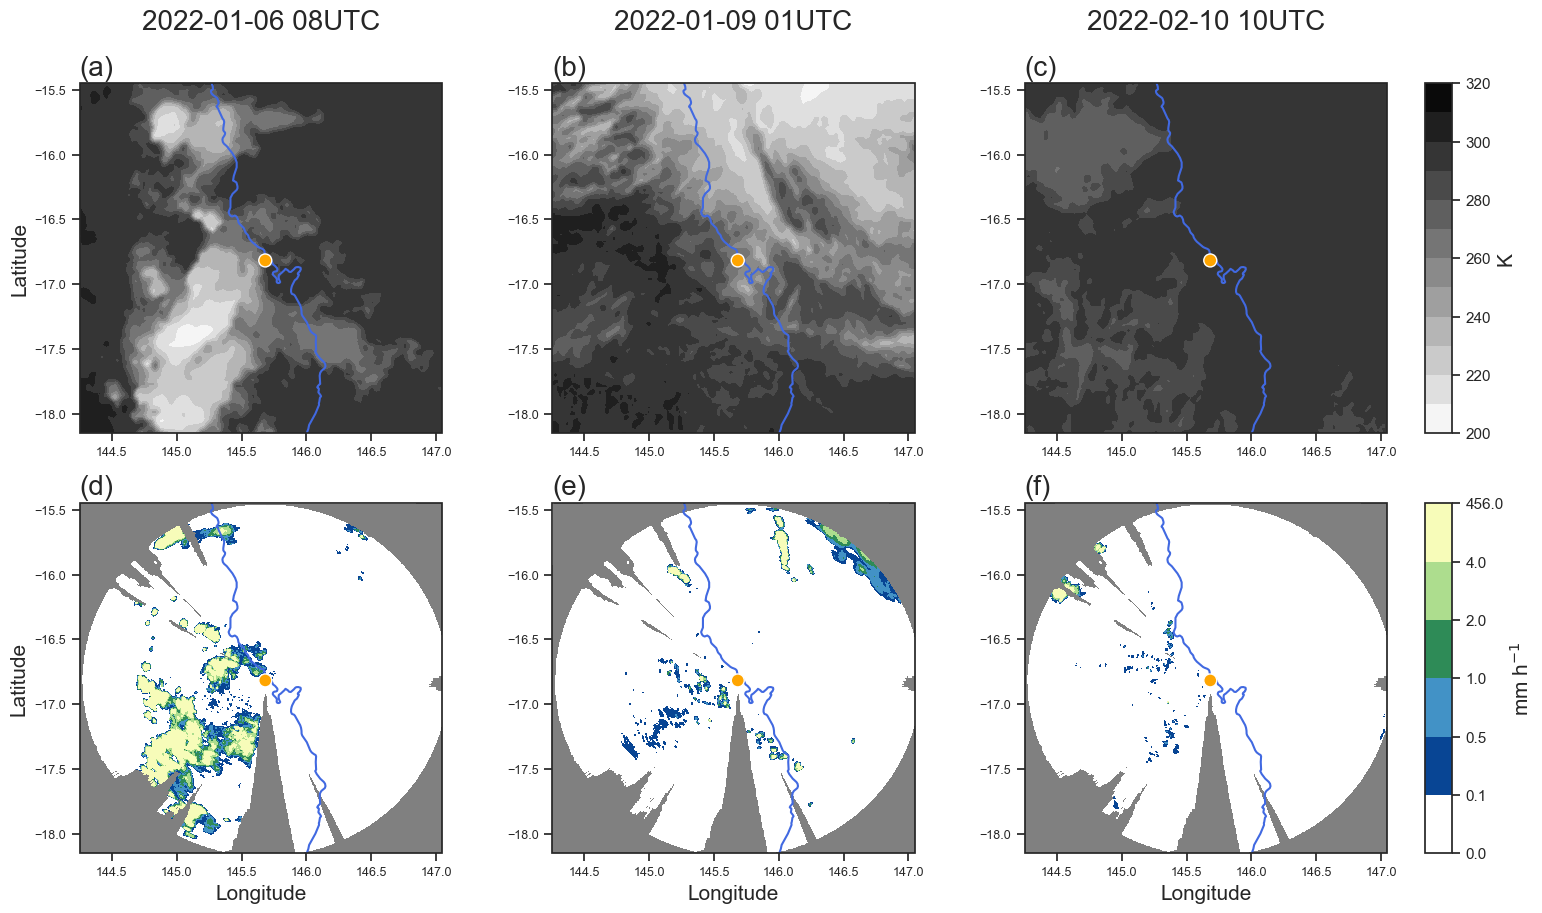

In [54]:
sns.set_theme(style="ticks")
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10),
    subplot_kw={"projection": proj},
    # constrained_layout=True,
    # gridspec_kw={"wspace": 0.01}
)
fig.patch.set_facecolor("white")
title_fontsize=20
label_fontsize=15
# x_sat = case_study_jam.lon.values
# y_sat = case_study_jam.lat.values
# x_rad = ds.lon.isel(time=0).values
# y_rad = ds.lat.isel(time=0).values
# print('computed lat lons')
# # pre-compute all three ±30min averages in one go
snapshots = [
    "2022-01-06T08:00:00",
    "2022-01-09T01:00:00",
    "2022-02-10T10:00:00",
]

rain_masked = ds.rainrate.where(mask_bb)  # mask once
# print('computed radar mask ds')
# z_rads = []
# for snapshot in snapshots:
#     t_center = pd.Timestamp(snapshot)
#     z = rain_masked.sel(time=slice(t_center - pd.Timedelta('30min'),
#                                    t_center + pd.Timedelta('30min'))).mean('time')
#     z_rads.append(z)

# z_rads = xr.concat(z_rads, dim='snapshot').compute()  # single compute call
# z_rads = rain_masked.sel(time=snapshot)#.mean('time')
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
# print('computed radar z')

sat_levels = np.arange(200, 330, 10)
rad_levels = [0, 0.1, 0.5, 1, 2, 4, 456]
rad_colors = ["white",'#084594', '#4292c6', 'seagreen', '#addd8e', '#f7fcb9']

for i, snapshot in enumerate(snapshots):
    t_center = pd.Timestamp(snapshot)
    t0 = t_center - pd.Timedelta('30min')
    t1 = t_center + pd.Timedelta('30min')

    # --- row 0: satellite ---
    ax_sat = axes[0, i]
    z_sat = case_study_jam.ch13BT.sel(time=snapshot)
    cf_sat = ax_sat.contourf(x_sat, y_sat, z_sat, levels=sat_levels, cmap="binary", transform=proj)
    ax_sat.set_extent([144.25, 147.05, -18.15, -15.45], crs=proj)
    ax_sat.coastlines("10m", color="royalblue", linewidth=1.5)
    ax_sat.set_xticks(np.arange(144.5, 147.5, 0.5), crs=proj)
    ax_sat.set_yticks(np.arange(-18, -15, 0.5), crs=proj)
    ax_sat.tick_params(labelsize=9)
    if i == 0:
        ax_sat.set_ylabel("Latitude", fontsize=label_fontsize)
    ax_sat.set_title(f"{panel_labels[i]}", fontsize=title_fontsize, loc='left')
    ax_sat.set_title(f"{snapshot[:10]} {snapshot[11:13]}UTC", fontsize=title_fontsize, loc='center',y=1.13)

    # --- row 1: radar ---
    ax_rad = axes[1, i]
    z_rad = rain_masked.sel(time=snapshot)
    # z_rad = z_rads.isel(snapshot=i)
    ax_rad.pcolormesh(x_rad, y_rad, mask_bb == False, color="gray")
    cf_rad = ax_rad.contourf(x_rad, y_rad, z_rad, levels=rad_levels, colors=rad_colors)
    # cf_zeros = ax_rad.contourf(x_rad, y_rad, z_rad, levels=[0,0.1], colors="white")
    
    ax_rad.set_extent([144.25, 147.05, -18.15, -15.45], crs=proj)
    ax_rad.coastlines("10m", color="royalblue", linewidth=1.5)
    ax_rad.set_xticks(np.arange(144.5, 147.5, 0.5), crs=proj)
    ax_rad.set_yticks(np.arange(-18, -15, 0.5), crs=proj)
    ax_rad.set_xlabel("Longitude", fontsize=label_fontsize)
    ax_rad.tick_params(labelsize=9)
    if i == 0:
        ax_rad.set_ylabel("Latitude", fontsize=label_fontsize)
    ax_rad.set_title(f"{panel_labels[i+3]}", fontsize=title_fontsize, loc='left')

    # radar site marker
    for ax_ in [ax_sat, ax_rad]:
        ax_.add_patch(mpatches.Circle((145.683, -16.817), 0.05, fc="orange", transform=proj, zorder=5))
    # ax_sat.add_patch(mpatches.Circle((145.683, -16.817), 1.3,  fc="grey", alpha=0.2, transform=proj, zorder=4,edgecolor="gold"))

# --- colorbars ---
plt.draw()
pos_sat = axes[0, -1].get_position()
cax_sat = fig.add_axes([pos_sat.x1 + 0.01, pos_sat.y0, 0.015, pos_sat.height])
cbar_sat = fig.colorbar(cf_sat, cax=cax_sat)
cbar_sat.set_label("K", fontsize=label_fontsize)

pos_rad = axes[1, -1].get_position()
cax_rad = fig.add_axes([pos_rad.x1 + 0.01, pos_rad.y0, 0.015, pos_rad.height])
cbar_rad = fig.colorbar(cf_rad, cax=cax_rad)
cbar_rad.set_label(r"mm h$^{-1}$", fontsize=label_fontsize)

fig.subplots_adjust(wspace=0.05, hspace=0.2)
plt.show()
# fig.savefig('/home/563/ac9768/GBR/scripts/Paper_figures/f02v3.png',bbox_inches='tight',dpi=300)